In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px 
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest , f_classif
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score , recall_score , precision_score , f1_score
from sklearn.metrics import roc_curve , roc_auc_score 
import pickle
import shap

# 🏦 Bank Customer Dataset Schema

This notebook documents the schema of a customer dataset used for banking churn analysis. It includes feature descriptions, data types, and inferred meanings to guide preprocessing and modeling.

---

## 📋 Dataset Columns

| Column Name           | Data Type | Description (Inferred)                                      |
|-----------------------|-----------|--------------------------------------------------------------|
| `id`, `CustomerId`    | int64     | Unique identifiers for each customer.                        |
| `Surname`             | object    | Customer's last name.                                        |
| `CreditScore`         | int64     | Credit score of the customer.                                |
| `Geography`, `Gender` | object    | Categorical features representing location and gender.       |
| `Age`                 | float64   | Customer's age.                                              |
| `Tenure`              | int64     | Number of years the customer has been with the bank.         |
| `Balance`             | float64   | Account balance.                                             |
| `EstimatedSalary`     | float64   | Estimated annual salary.                                     |
| `NumOfProducts`       | int64     | Number of bank products the customer uses.                   |
| `HasCrCard`           | float64   | Binary flag: 1 if customer has a credit card, else 0.        |
| `IsActiveMember`      | float64   | Binary flag: 1 if customer is active, else 0.                |
| `Exited`              | int64     | Target variable: 1 if customer exited (churned), else 0.     |

---

## 🧭 Notes

- Binary flags (`HasCrCard`, `IsActiveMember`) are stored as `float64`, which may require conversion to `int` or `bool` for modeling.
- Categorical features (`Geography`, `Gender`) may need encoding (e.g., one-hot or label encoding).
- `Exited` is the target variable for churn prediction.

---

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.drop(columns=['id' , 'CustomerId' , 'Surname'],inplace=True)

In [4]:
X = df.drop(columns='Exited')
y = df['Exited']

In [5]:
numerical_col = X.select_dtypes(exclude="O").columns

In [6]:
numerical_col

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [8]:
preprocessing = ColumnTransformer(
    transformers=[
        ("categorical" , OneHotEncoder(sparse_output=False, handle_unknown="ignore") , ["Gender", "Geography"]),
        ("numerical" , "passthrough" , numerical_col)
    ],
    remainder="passthrough"
)

In [9]:
xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [10]:
pipeline = Pipeline(
    [
        ("preprocessing" , preprocessing),
        ("smote" , SMOTE(random_state=42)),
        ("model" , xgb_classifier)
    ]
)

In [11]:
pipeline

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [12]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [13]:
y_pred_proba = pipeline.predict_proba(X_test)[: , 1]

threshold_grid = np.linspace(0.2, 0.8, 61)
best_threshold = max(
    threshold_grid,
    key=lambda t: f1_score(y_test, (y_pred_proba >= t).astype(int))
)
y_pred = (y_pred_proba >= best_threshold).astype(int)

In [14]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[: , 1]

In [15]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

auc = roc_auc_score(y_test , y_pred_proba)

In [16]:
print("Best threshold for F1 : ", round(best_threshold, 3))
print("Accuracy of the model : ", accuracy)
print("Precision of the model : ", precision)
print("Recall of the model : ", recall)
print("F1-score of the model : ", f1)
print("Auc-Roc of the model : ", auc)

Best threshold for F1 :  0.34
Accuracy of the model :  0.8662404944405732
Precision of the model :  0.7315827862873815
Recall of the model :  0.5768511861969806
F1-score of the model :  0.645067931505748
Auc-Roc of the model :  0.8890042621167


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Create ROC curve
fig = px.line(
    x=fpr,
    y=tpr,
    title=f"ROC Curve (AUC = {auc:.3f})",
    labels={"x": "False Positive Rate", "y": "True Positive Rate"}
)

# Add diagonal (random model)
fig.add_scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random Model',
    line=dict(dash='dash')
)

fig.show()

In [18]:
pickle.dump(pipeline,open('pipeline.pkl','wb')) 

In [19]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_classifier)

# Transform data using preprocessing pipeline
X_test_transformed = preprocessing.transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

In [20]:
feature_names = preprocessing.get_feature_names_out()

In [21]:
feature_names

array(['categorical__Gender_Female', 'categorical__Gender_Male',
       'categorical__Geography_France', 'categorical__Geography_Germany',
       'categorical__Geography_Spain', 'numerical__CreditScore',
       'numerical__Age', 'numerical__Tenure', 'numerical__Balance',
       'numerical__NumOfProducts', 'numerical__HasCrCard',
       'numerical__IsActiveMember', 'numerical__EstimatedSalary'],
      dtype=object)

# SHAP Feature Importance Analysis

**SHAP was used to interpret the XGBoost model and understand feature-level contributions to customer churn predictions**

Key observations:
- Features such as Number of Products , Age , isActiveMember , Gender and Balance
  had the highest impact on churn probability.
- Higher age and lower engagement indicators increased churn risk.
- SHAP explanations improve trust and interpretability, making the model
  suitable for real-world business decision-making.


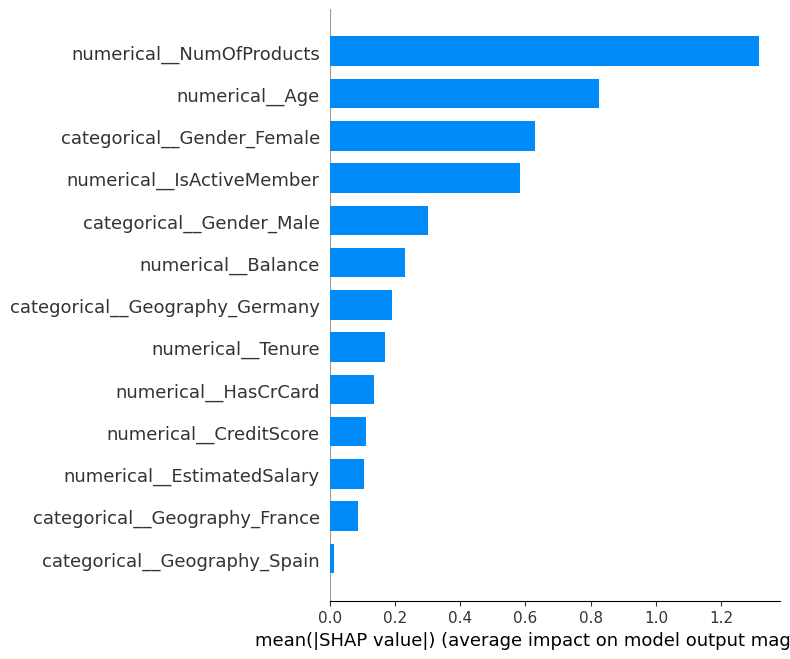

In [22]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

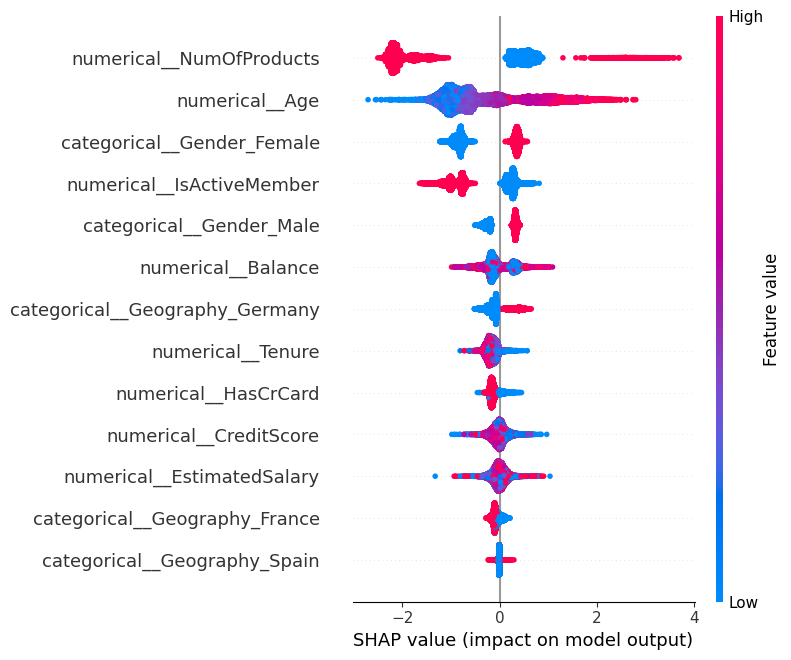

In [23]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)